# HW5 Mason Holcombe

In [77]:
import gensim
import gensim.downloader as api

from sklearn.metrics.pairwise import cosine_similarity

import matplotlib.pyplot as plt

# 1)

In [18]:
EMBEDDING_DIM = 300
WINDOW_SIZE = 3

dataset = api.load("text8")
model = gensim.models.Word2Vec(sentences=dataset,
                               vector_size=EMBEDDING_DIM,
                               window=WINDOW_SIZE)

print(f"STEP 1 | Completed {EMBEDDING_DIM} dim training.")

STEP 1 | Completed 300 dim training.


In [44]:
similar_words = [
    ("king", "queen"),
    ("fast", "quick"),
    ("begin", "start"),
    ("ocean", "sea"),
    ("hot", "warm")
]

print(f"STEP 1 | Similarity Scores:")
for w1, w2 in similar_words:
    wv1 = model.wv[w1].reshape(1, -1)
    wv2 = model.wv[w2].reshape(1, -1)

    sim_score = cosine_similarity(wv1, wv2).item()

    print(f"\t({w1}, {w2}) -> {sim_score:.4f}")

STEP 1 | Similarity Scores:
	(king, queen) -> 0.6288
	(fast, quick) -> 0.6691
	(begin, start) -> 0.6856
	(ocean, sea) -> 0.5627
	(hot, warm) -> 0.7472


# 2)

In [46]:
print(f"STEP 2 | Downloading google-news-300...")
pretrained_model = api.load('word2vec-google-news-300')
print(f"STEP 2 | Download complete.")

STEP 2 | Downloading google-news-300...
STEP 2 | Download complete.


In [47]:
word_categories = {
    "animals": [
        ("bird", "pigeon"),
        ("crocodile", "alligator"),
        ("mammoth", "elephant")
    ],
    "places": [
        ("paris", "france"),
        ("rome", "italy"),
        ("madrid", "spain")
    ],
    "colors": [
        ("red", "orange"),
        ("yellow", "green"),
        ("black", "white")
    ]
}

In [51]:
for category_type, pair_list in word_categories.items():
    for w1, w2 in pair_list:
        wv1 = model.wv[w1].reshape(1, -1)
        wv2 = model.wv[w2].reshape(1, -1)

        sim_score = cosine_similarity(wv1, wv2).item()

        print(f"{category_type} - ({w1}, {w2}) -> {sim_score:.4f}")
    print('\n')

animals - (bird, pigeon) -> 0.5474
animals - (crocodile, alligator) -> 0.6054
animals - (mammoth, elephant) -> 0.5011


places - (paris, france) -> 0.6154
places - (rome, italy) -> 0.6300
places - (madrid, spain) -> 0.5789


colors - (red, orange) -> 0.5243
colors - (yellow, green) -> 0.7047
colors - (black, white) -> 0.6697




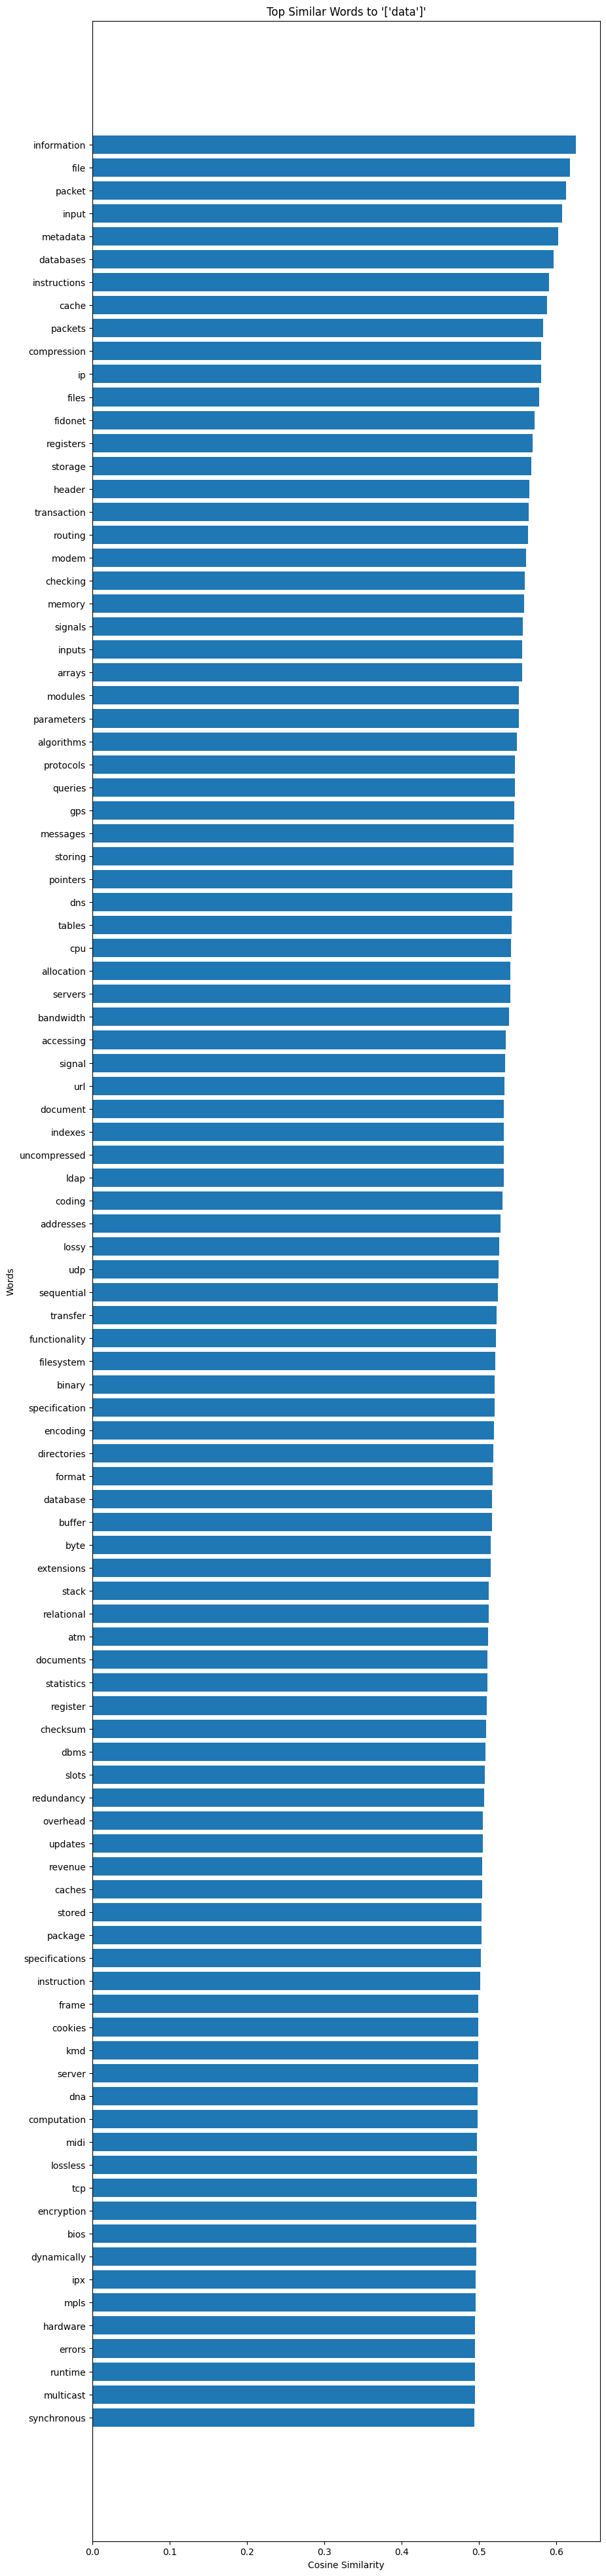

In [78]:

word = ["data"]

topn_similar = model.wv.most_similar(word, topn=100)

words = [w for w, _ in topn_similar]
scores = [s for _, s in topn_similar]

plt.figure(figsize=(10, 50))
plt.barh(words, scores)

plt.xlabel("Cosine Similarity")
plt.ylabel("Words")
plt.title(f"Top Similar Words to '{word}'")

plt.gca().invert_yaxis()  # highest at top
plt.show()